# RTX 5060 SFH fast-path posterior

- Galaxy: `M1_210210`.
- Samples use normalized nested-sampling weights.
- Figures remain inside this executed notebook.

In [1]:
from pathlib import Path
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

%config InlineBackend.figure_format = 'retina'
plt.style.use('seaborn-v0_8-whitegrid')

result_dir = Path.cwd()
fast_dir = result_dir / 'fastpath_a'
run_path = fast_dir / 'run.json'
result_path = fast_dir / 'ceridwen_result.h5'

if not run_path.exists() or not result_path.exists():
    raise FileNotFoundError('Run this notebook from its result directory.')

run = json.loads(run_path.read_text())
with h5py.File(result_path, 'r') as handle:
    samples = {
        name: np.asarray(handle[f'samples/{name}'])
        for name in run['result']['param_names']
    }
    log_weights = np.asarray(handle['samples/log_weights'])
    log_likelihoods = np.asarray(handle['samples/log_likelihoods'])

weights = np.exp(log_weights - np.max(log_weights))
weights /= weights.sum()
posterior_ess = 1.0 / np.sum(weights**2)

run['status'], result_path.name

('complete', 'ceridwen_result.h5')

## Run contract

- These values define the completed scientific run.

In [2]:
workload = run['contract']['workload']
sampler = run['contract']['sampler']
result = run['result']
contract_rows = [
    ('Galaxy', workload['target']),
    ('Redshift', workload['redshift']),
    ('Spectrum pixels', workload['spectral_pixels']),
    ('Photometric bands', workload['photometric_bands']),
    ('GPU', run['contract']['software']['device']),
    ('NSS live points', sampler['num_live']),
    ('NSS inner steps', sampler['num_inner_steps']),
    ('Evidence tolerance', sampler['logZ_tol']),
    ('Nested samples', result['n_samples']),
    ('Likelihood calls', result['n_likelihood_calls']),
    ('Sampler time [s]', result['wall_time_s']),
    ('Calls per second', result['n_likelihood_calls'] / result['wall_time_s']),
    ('log evidence', result['log_evidence']),
    ('log evidence error', result['log_evidence_err']),
    ('Posterior-weight ESS', posterior_ess),
]
contract_table = pd.DataFrame(contract_rows, columns=['Quantity', 'Value'])
display(contract_table.style.hide(axis='index').format({'Value': lambda value: f'{value:.6g}' if isinstance(value, float) else value}))

Quantity,Value
Galaxy,M1_210210
Redshift,0.6542
Spectrum pixels,3523
Photometric bands,11
GPU,NVIDIA GeForce RTX 5060
NSS live points,300
NSS inner steps,40
Evidence tolerance,-3
Nested samples,13850
Likelihood calls,542000


## Weighted posterior summary

- Each interval contains the central 68 percent probability.

In [3]:
def weighted_quantiles(values, probabilities, sample_weights):
    order = np.argsort(values)
    sorted_values = np.asarray(values)[order]
    cumulative = np.cumsum(np.asarray(sample_weights)[order])
    cumulative /= cumulative[-1]
    return np.interp(probabilities, cumulative, sorted_values)


components = []
for name in run['result']['param_names']:
    values = np.asarray(samples[name]).reshape(len(weights), -1)
    for index in range(values.shape[1]):
        label = name if values.shape[1] == 1 else f'{name}[{index}]'
        components.append((label, values[:, index]))

summary_rows = []
for label, values in components:
    q16, median, q84 = weighted_quantiles(values, [0.16, 0.50, 0.84], weights)
    mean = np.sum(weights * values)
    sd = np.sqrt(np.sum(weights * (values - mean) ** 2))
    summary_rows.append(
        {
            'Parameter': label,
            'Mean': mean,
            'Median': median,
            '16th percentile': q16,
            '84th percentile': q84,
            'Weighted SD': sd,
        }
    )

summary_table = pd.DataFrame(summary_rows)
display(summary_table.style.hide(axis='index').format(precision=5))

Parameter,Mean,Median,16th percentile,84th percentile,Weighted SD
Z,-1.24826,-1.24542,-1.26039,-1.23679,0.01201
afe,0.01118,0.01106,0.00328,0.01871,0.00788
diffuse_tau_kc,0.29786,0.29794,0.28925,0.30640,0.00891
logsfr_ratios[0],-1.89557,-1.97591,-2.66892,-1.08886,0.70345
logsfr_ratios[1],2.02335,2.06336,1.42583,2.59212,0.53039
logsfr_ratios[2],-0.67060,-0.68342,-1.24745,-0.08124,0.57096
logsfr_ratios[3],-2.42941,-2.44210,-2.79502,-2.07903,0.33227
logsfr_ratios[4],0.66079,0.69253,0.42493,0.88047,0.23089
logsfr_ratios[5],-0.80486,-0.85897,-1.06195,-0.53980,0.29747
logsfr_ratios[6],0.22541,0.20804,-0.18083,0.65326,0.39539


## Posterior distributions

- Shading marks each central 68 percent interval.

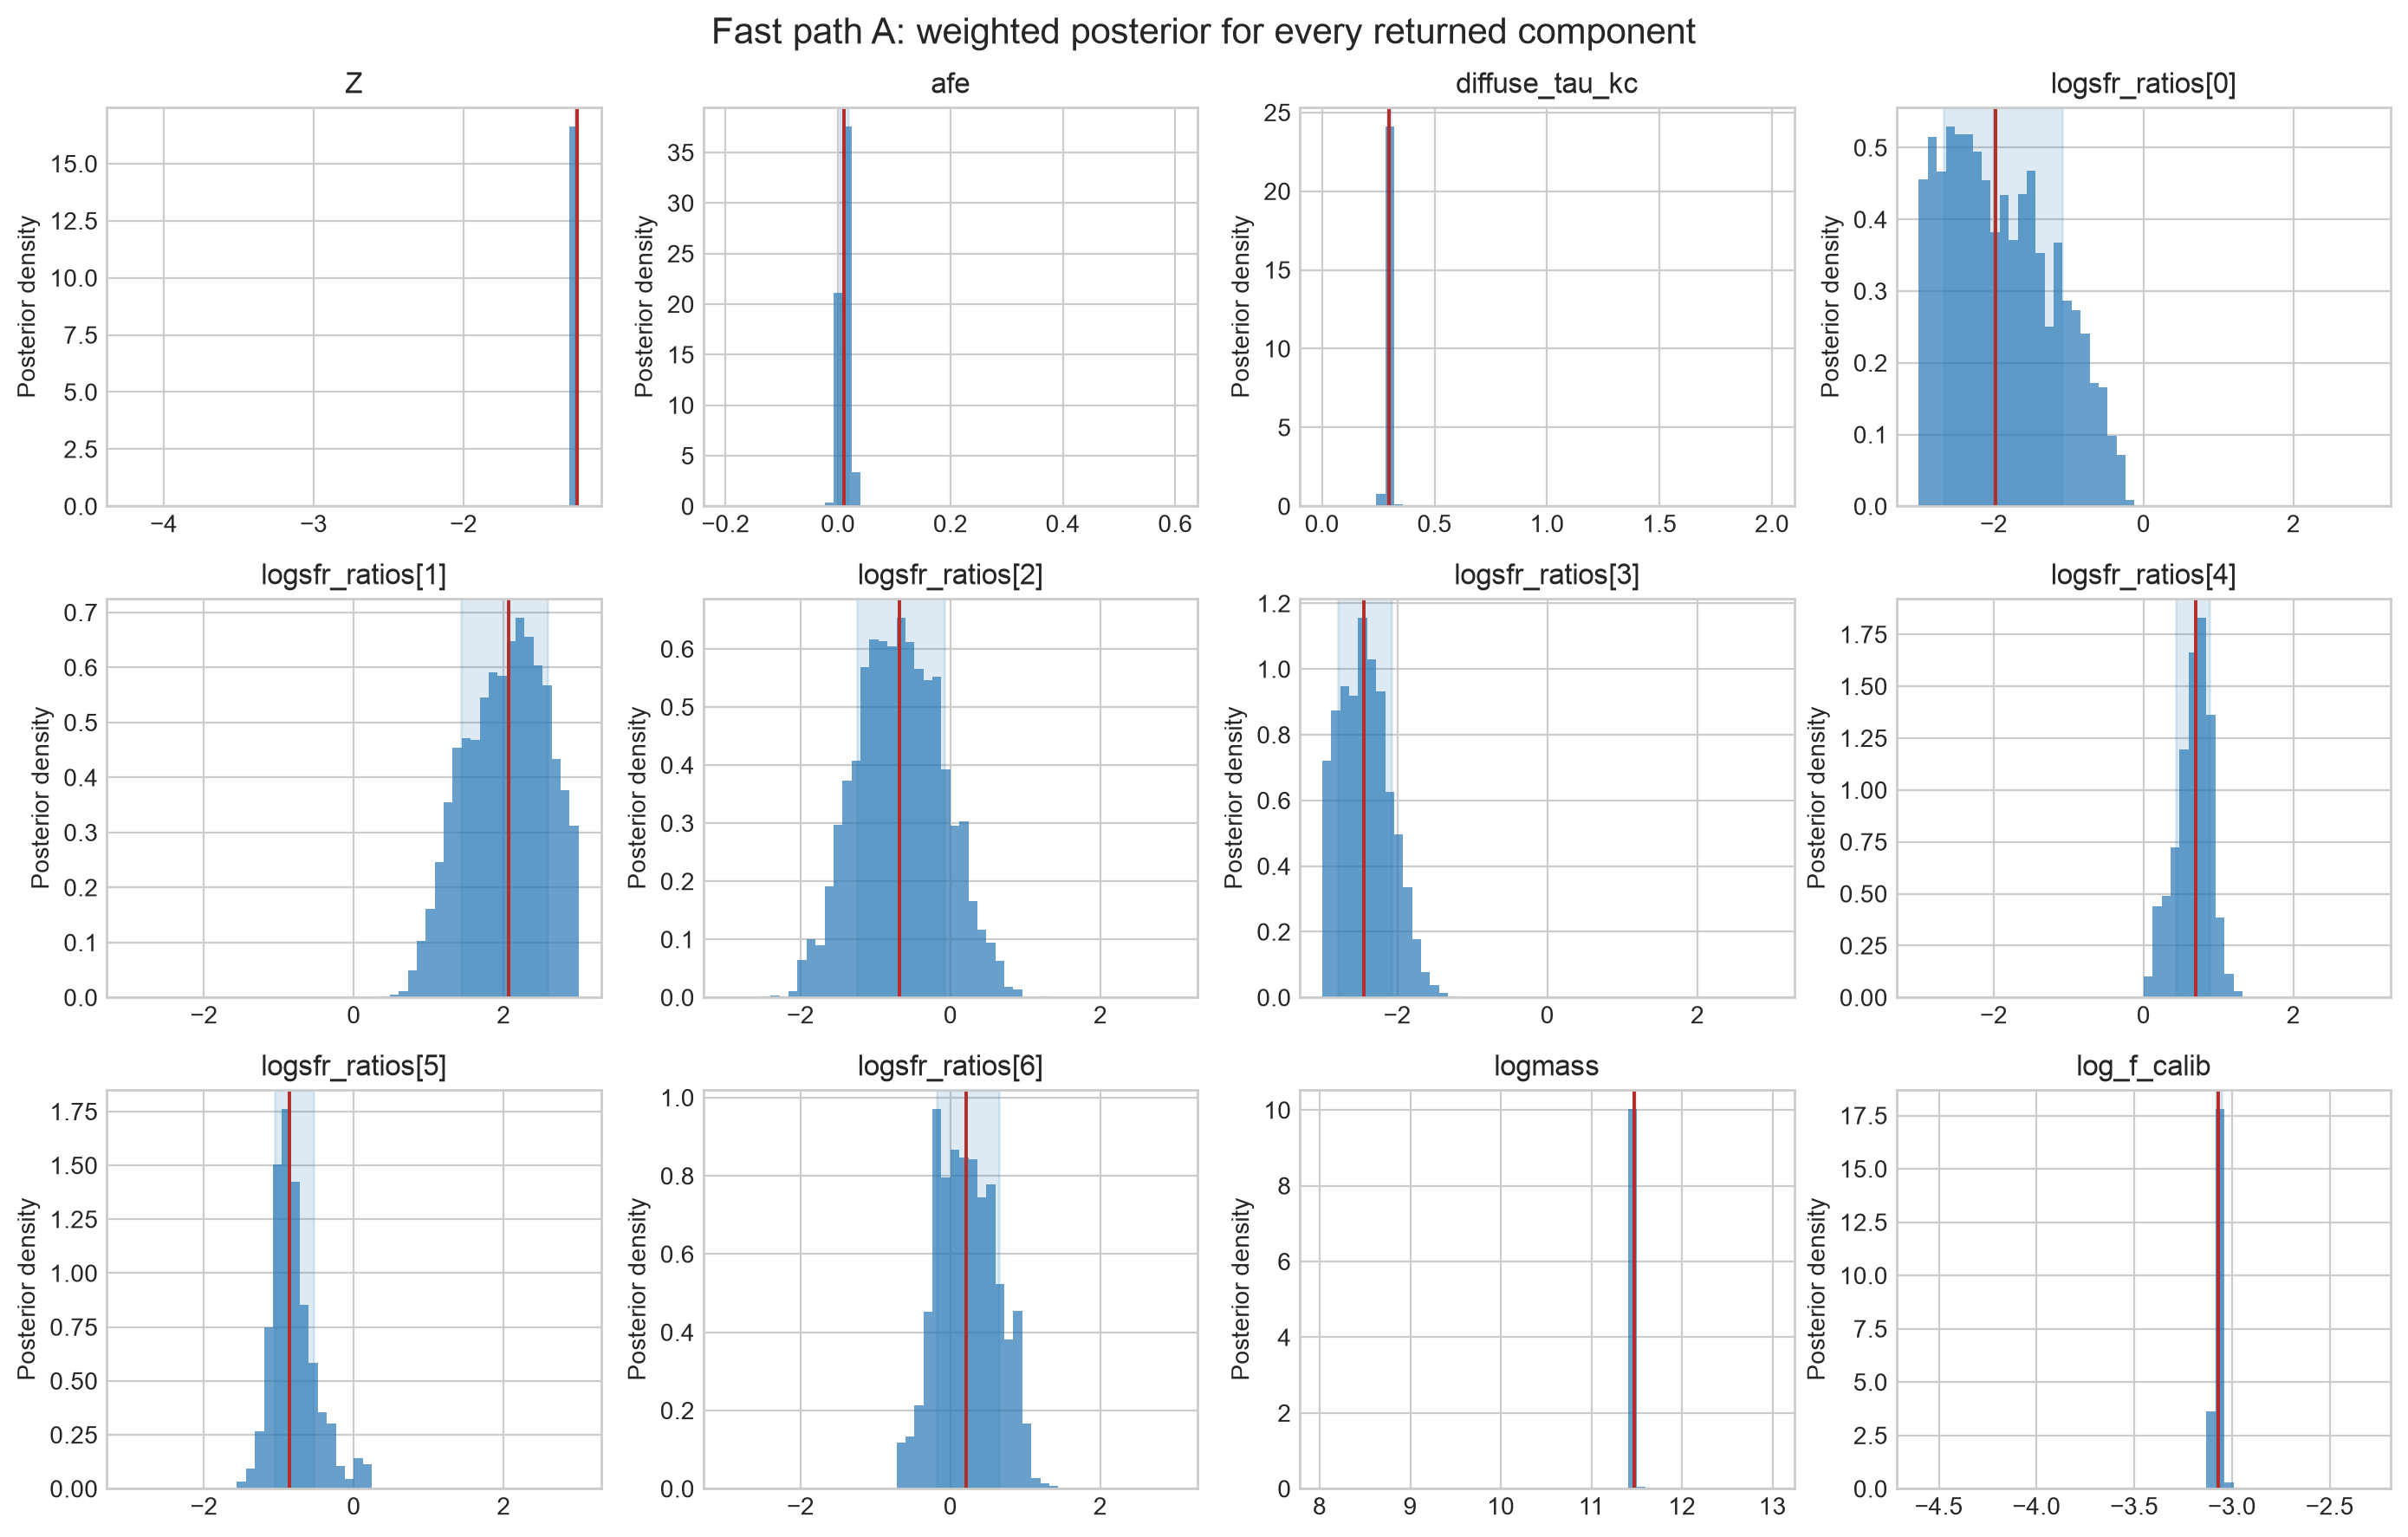

In [4]:
figure, axes = plt.subplots(3, 4, figsize=(14, 9))
for axis, (label, values) in zip(axes.flat, components, strict=True):
    q16, median, q84 = weighted_quantiles(values, [0.16, 0.50, 0.84], weights)
    axis.hist(
        values,
        bins=50,
        weights=weights,
        density=True,
        color='#2878B5',
        alpha=0.70,
        edgecolor='none',
    )
    axis.axvspan(q16, q84, color='#2878B5', alpha=0.15)
    axis.axvline(median, color='#B52B27', linewidth=1.4)
    axis.set_title(label)
    axis.set_ylabel('Posterior density')
figure.suptitle('Fast path A: weighted posterior for every returned component', fontsize=15)
figure.tight_layout()
plt.show()

## Nested-sampling diagnostics

- Dead points move from low to high likelihood.
- Posterior mass accumulates near the final contours.

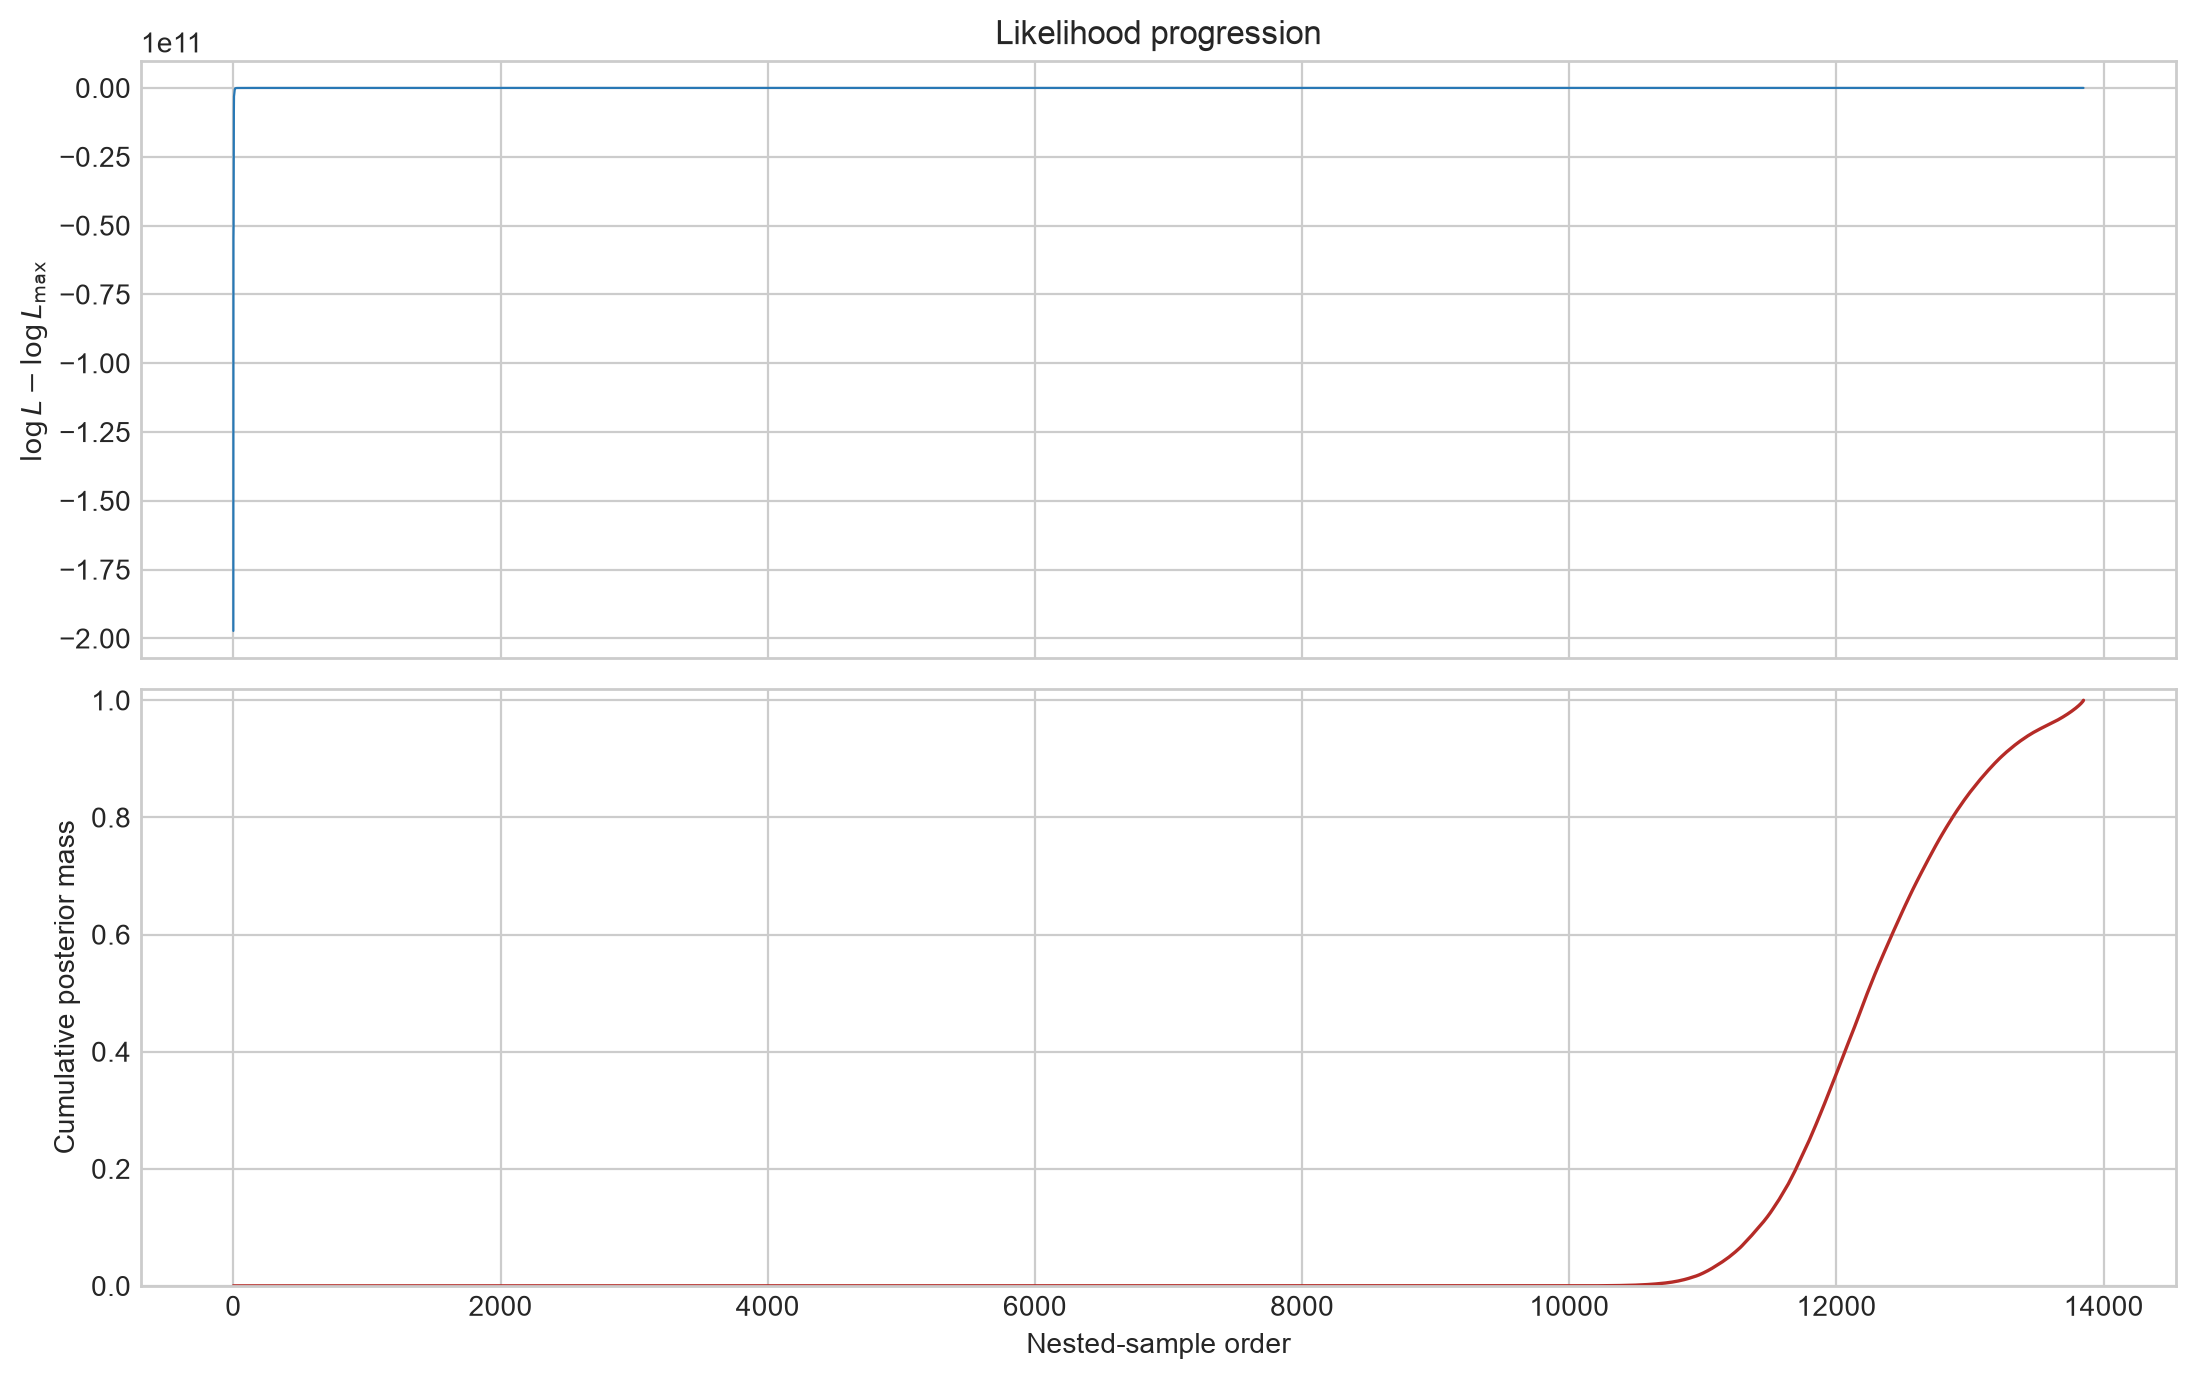

In [5]:
relative_log_likelihood = log_likelihoods - np.max(log_likelihoods)
cumulative_mass = np.cumsum(weights)

figure, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(relative_log_likelihood, color='#2878B5', linewidth=0.8)
axes[0].set_ylabel(r'$\log L - \log L_{\max}$')
axes[0].set_title('Likelihood progression')
axes[1].plot(cumulative_mass, color='#B52B27', linewidth=1.2)
axes[1].set_xlabel('Nested-sample order')
axes[1].set_ylabel('Cumulative posterior mass')
axes[1].set_ylim(0, 1.02)
figure.tight_layout()
plt.show()

## Matched baseline comparison

- This section activates when the baseline files arrive.

In [6]:
baseline_path = result_dir / 'baseline' / 'ceridwen_result.h5'
comparison_path = result_dir / 'comparison.json'

if not baseline_path.exists():
    display(Markdown('The matched baseline is still running. The fast-run posterior above is complete.'))
else:
    with h5py.File(baseline_path, 'r') as handle:
        baseline_samples = {
            name: np.asarray(handle[f'samples/{name}'])
            for name in run['result']['param_names']
        }
        baseline_log_weights = np.asarray(handle['samples/log_weights'])

    baseline_weights = np.exp(baseline_log_weights - np.max(baseline_log_weights))
    baseline_weights /= baseline_weights.sum()
    baseline_components = []
    for name in run['result']['param_names']:
        values = np.asarray(baseline_samples[name]).reshape(len(baseline_weights), -1)
        for index in range(values.shape[1]):
            label = name if values.shape[1] == 1 else f'{name}[{index}]'
            baseline_components.append((label, values[:, index]))

    figure, axes = plt.subplots(3, 4, figsize=(14, 9))
    for axis, fast_component, baseline_component in zip(
        axes.flat, components, baseline_components, strict=True
    ):
        label, fast_values = fast_component
        baseline_label, baseline_values = baseline_component
        if label != baseline_label:
            raise ValueError(f'Parameter order differs for {label}.')
        pooled = np.concatenate([fast_values, baseline_values])
        bins = np.linspace(np.min(pooled), np.max(pooled), 51)
        axis.hist(
            baseline_values, bins=bins, weights=baseline_weights, density=True,
            histtype='step', linewidth=1.5, color='0.2', label='Baseline',
        )
        axis.hist(
            fast_values, bins=bins, weights=weights, density=True,
            histtype='step', linewidth=1.5, color='#2878B5', label='Fast A',
        )
        axis.set_title(label)
        axis.set_ylabel('Posterior density')
    axes.flat[0].legend(frameon=False)
    figure.suptitle('Matched converged posteriors', fontsize=15)
    figure.tight_layout()
    plt.show()

    if comparison_path.exists():
        comparison = json.loads(comparison_path.read_text())
        comparison_rows = [
            {
                'Parameter': item['parameter'],
                'Mean shift [pooled SD]': item['mean_shift_pooled_sd'],
                'Median shift [pooled SD]': item['median_shift_pooled_sd'],
                'Wasserstein [pooled SD]': item['wasserstein_pooled_sd'],
                'Passed': item['passed'],
            }
            for item in comparison['parameters']
        ]
        display(Markdown(f"**Equivalence result: {comparison['status'].upper()}**"))
        display(pd.DataFrame(comparison_rows).style.hide(axis='index').format(precision=4))

The matched baseline is still running. The fast-run posterior above is complete.